In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from kagraph import END, START, StateGraph, add_messages, invoke_llm
from kagraph.llms import load_llm
from kagraph.messages import AIMessage, AnyMessage, HumanMessage
from kagraph.tracing import trace

In [2]:
SUPPORT_SYSTEM = (
    "You are a customer support agent for an airline. Be polite, concise, and "
    "policy-aware. You may not promise refunds for trips that happened five "
    "years ago, but you should explain the policy and next steps."
)

CUSTOMER_SYSTEM = (
    "You are Harrison, a customer of an airline company. You are trying to get "
    "a full refund. You are persistent but realistic. When the support agent "
    "has clearly explained the policy and next steps, respond with exactly "
    "FINISHED."
)

In [3]:
class SimulationInput(TypedDict):
    customer_request: str


class SimulationState(TypedDict, total=False):
    customer_request: str
    messages: Annotated[list[AnyMessage], add_messages]


In [4]:
def _message_text(message: AnyMessage) -> str:
    text = getattr(message, "text", None)
    if text is not None:
        return str(text)
    return str(getattr(message, "content", ""))


def _message_role(message: AnyMessage) -> str:
    sender = getattr(message, "sender", None)
    return str(getattr(sender, "role", getattr(message, "role", "assistant")))


def _messages_for_customer(messages: list[AnyMessage]) -> list[AnyMessage]:
    """Flip the transcript so the customer simulator sees support as the user."""

    swapped: list[AnyMessage] = []
    for message in messages:
        text = _message_text(message)
        if not text:
            continue

        role = _message_role(message)
        if role == "assistant":
            swapped.append(HumanMessage(text))
        elif role == "user":
            swapped.append(AIMessage(text))
    return swapped

In [5]:
def build_graph(llm):
    graph = StateGraph(SimulationState, input_schema=SimulationInput)

    def prepare_customer_request(state: SimulationInput):
        return {
            "customer_request": state["customer_request"],
            "messages": [
                HumanMessage(
                    "Hi, I need help with this airline support request:\n\n"
                    f"{state['customer_request']}"
                )
            ],
        }

    def chat_bot_node(state: SimulationState):
        response = invoke_llm(
            llm,
            messages=state["messages"],
            prompt="Respond as the airline support agent.",
            system=SUPPORT_SYSTEM,
        )
        return {"messages": [response]}

    def simulated_customer_node(state: SimulationState):
        response = invoke_llm(
            llm,
            messages=_messages_for_customer(state["messages"]),
            prompt=(
                "Respond as Harrison, the customer. Keep the conversation moving "
                "toward resolving this request:\n\n"
                f"{state['customer_request']}"
            ),
            system=CUSTOMER_SYSTEM,
        )
        return {"messages": [HumanMessage(response.text)]}

    def should_continue(state: SimulationState):
        messages = state["messages"]
        if len(messages) >= 10:
            return "end"
        if _message_text(messages[-1]).strip().upper() == "FINISHED":
            return "end"
        return "continue"

    graph.add_node(
        "prepare_customer_request",
        prepare_customer_request,
        input_schema=SimulationInput,
    )
    graph.add_node("chat_bot", chat_bot_node)
    graph.add_node("customer", simulated_customer_node)

    graph.add_edge(START, "prepare_customer_request")
    graph.add_edge("prepare_customer_request", "chat_bot")
    graph.add_edge("chat_bot", "customer")
    graph.add_conditional_edges(
        "customer",
        should_continue,
        {
            "continue": "chat_bot",
            "end": END,
        },
    )

    return graph.compile(name="agent_simulation_evaluation")

In [6]:
llm = load_llm("qwen/qwen3-next-80b-a3b-instruct")
app = build_graph(llm)

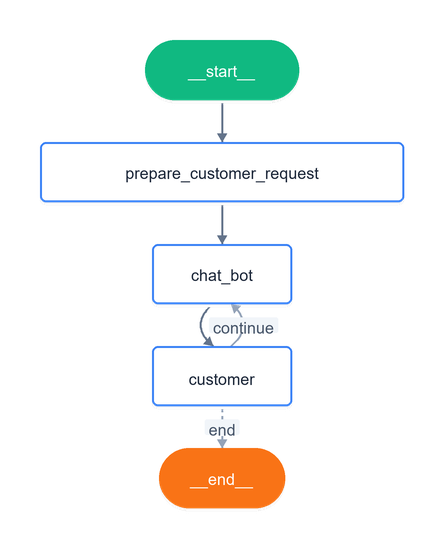

In [7]:
app.get_graph().draw_png()

In [8]:
with trace("AgentSimulationEvaluation"):
    result = app.invoke(
        {
            "customer_request": (
                "My name is Harrison. I want a full refund for a trip to Alaska "
                "that happened five years ago."
            )
        },
        chat_name="KaGraph Agent Simulation Evaluation tutorial",
        recursion_limit=12,
    )